In [1]:
import pandas as pd

df = pd.read_csv(
    "../ubernymaio14.csv",
    nrows = 20000
)

print(df.head())

df_original = df.copy()


          Date/Time      Lat      Lon    Base
0  5/1/2014 0:02:00  40.7521 -73.9914  B02512
1  5/1/2014 0:06:00  40.6965 -73.9715  B02512
2  5/1/2014 0:15:00  40.7464 -73.9838  B02512
3  5/1/2014 0:17:00  40.7463 -74.0011  B02512
4  5/1/2014 0:17:00  40.7594 -73.9734  B02512


In [2]:

print("valores nulos encontrado :" , df.isnull().sum())

# Verificar e remover duplicatas
print("valores duplicados :" , df.duplicated().sum())
df = df.drop_duplicates()


valores nulos encontrado : Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64
valores duplicados : 780


In [3]:

df['Date/Time'] = pd.to_datetime(df['Date/Time'])
df['Hour'] = df['Date/Time'].dt.hour
df['Day'] = df['Date/Time'].dt.day

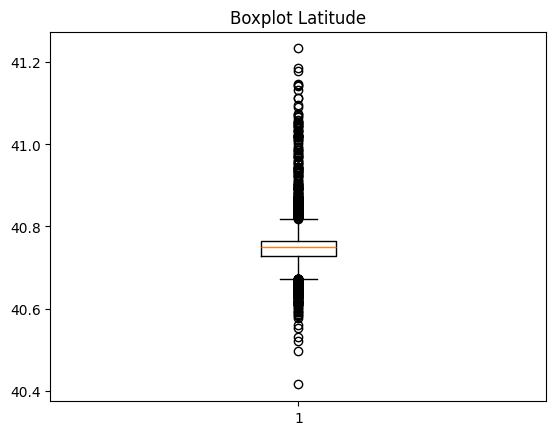

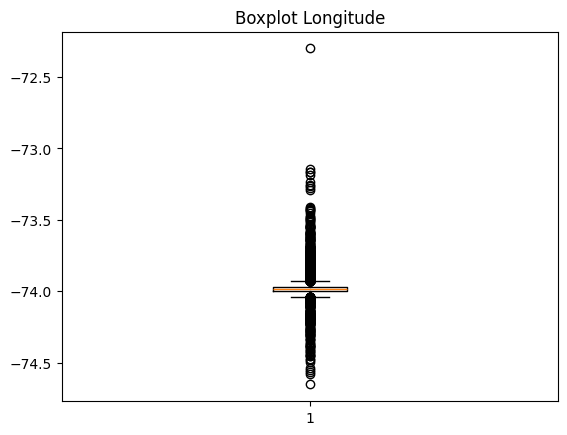

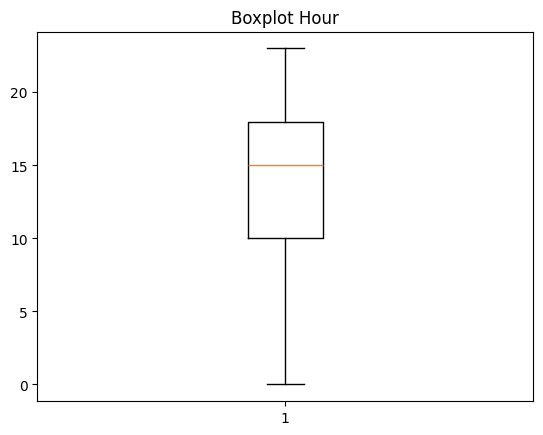

min latitude 40.4152
max latitude 41.2336
min longitude -74.6521
max longitude -72.2999
min hour 0
max hour 23


In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['Lat'])
plt.title("Boxplot Latitude")
plt.show()

plt.boxplot(df['Lon'])
plt.title("Boxplot Longitude")
plt.show()


plt.boxplot(df['Hour'])
plt.title("Boxplot Hour")
plt.show()



print("min latitude" , df['Lat'].min())
print("max latitude" , df['Lat'].max())
print("min longitude" , df['Lon'].min())
print("max longitude" , df['Lon'].max())
print("min hour" , df['Hour'].min())
print("max hour" , df['Hour'].max())

# Não foi necessaria a remoção de outliers,
# pois os valores observados de latitude, longitude e hora
# permaneceram dentro do intervalo esperado para o contexto do dataset.



In [6]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Lat', 'Lon', 'Hour']] = scaler.fit_transform(
    df[['Lat', 'Lon', 'Hour']]
)

In [7]:
df.to_csv(
    "../ubernymaio14_tratado.csv",
    index=False
)

In [19]:
print("===== TIPOS ORIGINAIS =====")
print(df_original.dtypes)

print("\n===== TIPOS TRATADOS =====")
print(df.dtypes)


print("\nColunas do dataset original:")
print(df_original.columns)

print("Colunas do dataset tratado:")
print(df.columns)




===== TIPOS ORIGINAIS =====
Date/Time        str
Lat          float64
Lon          float64
Base             str
dtype: object

===== TIPOS TRATADOS =====
Date/Time    datetime64[us]
Lat                 float64
Lon                 float64
Base                    str
Hour                float64
Day                   int32
dtype: object

Colunas do dataset original:
Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='str')
Colunas do dataset tratado:
Index(['Date/Time', 'Lat', 'Lon', 'Base', 'Hour', 'Day'], dtype='str')


In [13]:
print("===== LATITUDE ORIGINAL =====")
print(df_original['Lat'].head())

print("\n===== LATITUDE NORMALIZADA =====")
print(df['Lat'].head())

print("===== LONGITUDE ORIGINAL =====")
print(df_original['Lon'].head())

print("\n===== LONGITUDE NORMALIZADA =====")
print(df['Lon'].head())




===== LATITUDE ORIGINAL =====
0    40.7521
1    40.6965
2    40.7464
3    40.7463
4    40.7594
Name: Lat, dtype: float64

===== LATITUDE NORMALIZADA =====
0    0.411657
1    0.343719
2    0.404692
3    0.404570
4    0.420577
Name: Lat, dtype: float64
===== LONGITUDE ORIGINAL =====
0   -73.9914
1   -73.9715
2   -73.9838
3   -74.0011
4   -73.9734
Name: Lon, dtype: float64

===== LONGITUDE NORMALIZADA =====
0    0.280886
1    0.289346
2    0.284117
3    0.276762
4    0.288538
Name: Lon, dtype: float64


In [17]:
print("A coluna 'Hour' não existia no dataset original.")
print("Ela foi criada a partir da coluna Date/Time.\n")
print(df['Hour'].sample(10))

A coluna 'Hour' não existia no dataset original.
Ela foi criada a partir da coluna Date/Time.

4686     0.695652
19600    0.739130
12140    0.565217
8533     0.869565
12248    0.608696
9984     0.826087
14604    0.739130
8850     0.304348
19974    0.826087
3367     0.652174
Name: Hour, dtype: float64
